# Notebook 05 - Deep Neural Network

This notebook trains a feedforward neural network for multiclass IoT intrusion detection. We tune the model, track learning curves, evaluate it, and save the checkpoint.

## 1. Imports

Load PyTorch for the neural network and sklearn utilities for metrics and preprocessing support.

The code below imports PyTorch, sklearn metrics, numpy/pandas, and plotting utilities.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    classification_report,
    confusion_matrix,
    log_loss,
    recall_score
)

# Reproducibility seeds
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch version: {torch.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')
print(f'Device: {device}')

PyTorch version: 2.11.0+cu128
GPU available: True
Device: cuda


## 2. Load Preprocessed Data

Load the feature variants and labels from Notebook 2. The DNN will mainly use scaled variants.

The code below loads the processed feature variants and encoded labels from disk.

In [41]:
DATA_DIR = Path('../data/processed')
print('Using processed folder:', DATA_DIR.resolve())


def load_csv(name, base_dir=DATA_DIR):
    path = base_dir / name
    if not path.exists():
        raise FileNotFoundError(f'File not found: {path}')
    return pd.read_csv(path)


# --- Feature splits ---
X_train_raw        = load_csv('X_train_raw.csv')
X_val_raw          = load_csv('X_val_raw.csv')
X_test_raw         = load_csv('X_test_raw.csv')

X_train_out        = load_csv('X_train_out.csv')
X_val_out          = load_csv('X_val_out.csv')
X_test_out         = load_csv('X_test_out.csv')

X_train_scaled     = load_csv('X_train_scaled.csv')
X_val_scaled       = load_csv('X_val_scaled.csv')
X_test_scaled      = load_csv('X_test_scaled.csv')

X_train_out_scaled = load_csv('X_train_out_scaled.csv')
X_val_out_scaled   = load_csv('X_val_out_scaled.csv')
X_test_out_scaled  = load_csv('X_test_out_scaled.csv')

# --- Label splits ---
y_train_df = load_csv('y_train_encoded.csv')
y_val_df   = load_csv('y_val_encoded.csv')
y_test_df  = load_csv('y_test_encoded.csv')

for name, df in [('y_train', y_train_df), ('y_val', y_val_df), ('y_test', y_test_df)]:
    if df.shape[1] != 1:
        raise ValueError(f'{name}_encoded.csv must contain exactly one column.')

y_train = y_train_df.iloc[:, 0].to_numpy()
y_val   = y_val_df.iloc[:, 0].to_numpy()
y_test  = y_test_df.iloc[:, 0].to_numpy()

# --- Convert features to numpy ---
X_train_raw        = X_train_raw.to_numpy()
X_val_raw          = X_val_raw.to_numpy()
X_test_raw         = X_test_raw.to_numpy()

X_train_out        = X_train_out.to_numpy()
X_val_out          = X_val_out.to_numpy()
X_test_out         = X_test_out.to_numpy()

X_train_scaled     = X_train_scaled.to_numpy()
X_val_scaled       = X_val_scaled.to_numpy()
X_test_scaled      = X_test_scaled.to_numpy()

X_train_out_scaled = X_train_out_scaled.to_numpy()
X_val_out_scaled   = X_val_out_scaled.to_numpy()
X_test_out_scaled  = X_test_out_scaled.to_numpy()

# --- Organize into a dictionary ---
splits = {
    'raw':        {'X_train': X_train_raw,        'X_val': X_val_raw,        'X_test': X_test_raw},
    'out':        {'X_train': X_train_out,        'X_val': X_val_out,        'X_test': X_test_out},
    'scaled':     {'X_train': X_train_scaled,     'X_val': X_val_scaled,     'X_test': X_test_scaled},
    'out_scaled': {'X_train': X_train_out_scaled, 'X_val': X_val_out_scaled, 'X_test': X_test_out_scaled},
}

print('Data loaded successfully.')
print(f'Train: {y_train.shape[0]} samples | Val: {y_val.shape[0]} | Test: {y_test.shape[0]}')
print(f'Features: {X_train_raw.shape[1]} | Classes: {len(np.unique(y_train))}')

Using processed folder: C:\Users\user\Desktop\MyFiles\Uni\My_ML_Project\data\processed
Data loaded successfully.
Train: 901868 samples | Val: 193258 | Test: 193258
Features: 39 | Classes: 34


## 3. Select Feature Version

Neural networks train better when features are on similar scales. This is why the scaled and outlier-scaled variants are the main choices.

The code below selects the feature variant used for DNN training.

In [42]:
# Options: 'raw' | 'out' | 'scaled' | 'out_scaled'
# DNN requires scaling — 'out_scaled' is the correct choice
FEATURE_VERSION = 'out'

X_train = splits[FEATURE_VERSION]['X_train']
X_val   = splits[FEATURE_VERSION]['X_val']
X_test  = splits[FEATURE_VERSION]['X_test']
# y arrays are identical across all variants

print(f'Feature version selected: {FEATURE_VERSION}')
print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_val: {y_val.shape} | y_test: {y_test.shape}')

Feature version selected: out
X_train: (901868, 39) | X_val: (193258, 39) | X_test: (193258, 39)
y_train: (901868,) | y_val: (193258,) | y_test: (193258,)


## 4. Class Weights and Configuration

Use class weights in the loss function so rare classes are not ignored. Also set device and random seeds for a controlled run.

The code below loads class weights, chooses CPU/GPU, and sets training configuration values.

In [43]:
custom_class_weights = {
    '0':  12.325989503608135, '1':  0.757872268907563,  '2':  6.815398101686718,
    '3':  7.3579831932773105, '4':  0.757872268907563,  '5':  1.3730991516598356,
    '6':  0.757872268907563,  '7':  0.757872268907563,  '8':  0.757872268907563,
    '9':  0.757872268907563,  '10': 1.6917870662519743, '11': 0.757872268907563,
    '12': 0.757872268907563,  '13': 0.757872268907563,  '14': 0.757872268907563,
    '15': 0.757872268907563,  '16': 3.0266464413241336, '17': 0.757872268907563,
    '18': 0.757872268907563,  '19': 0.757872268907563,  '20': 0.757872268907563,
    '21': 0.757872268907563,  '22': 0.757872268907563,  '23': 0.757872268907563,
    '24': 0.757872268907563,  '25': 0.757872268907563,  '26': 0.757872268907563,
    '27': 0.757872268907563,  '28': 17.531744488938998, '29': 0.757872268907563,
    '30': 7.546381055978579,  '31': 31.69119404034015,  '32': 0.757872268907563,
    '33': 10.229668110977519
}
custom_class_weights = {int(k): float(v) for k, v in custom_class_weights.items()}

BENIGN_LABEL = 1  # BENIGN = class index 1 in Notebook 02's LabelEncoder
N_CLASSES    = len(np.unique(y_train))
ALL_LABELS   = np.arange(N_CLASSES)
N_FEATURES   = X_train.shape[1]

print(f'Classes: {N_CLASSES} | Features: {N_FEATURES}')
print(f'Min weight: {min(custom_class_weights.values()):.4f}  (majority classes)')
print(f'Max weight: {max(custom_class_weights.values()):.4f}  (rarest class)')
print(f'Benign label: {BENIGN_LABEL}')

Classes: 34 | Features: 39
Min weight: 0.7579  (majority classes)
Max weight: 31.6912  (rarest class)
Benign label: 1


## 5. Build the Neural Network

Define a simple feedforward DNN with hidden layers, batch normalization, dropout, and ReLU activations.

The code below defines the DNN class and its forward pass.

In [44]:
class DNN(nn.Module):
    '''3-hidden-layer DNN with BatchNorm and Dropout.'''
    def __init__(self, n_features, n_classes, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256, momentum=0.01),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128, momentum=0.01),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64, momentum=0.01),
            nn.Dropout(dropout_rate),

            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.net(x)


def build_model(n_features, n_classes, dropout_rate=0.3, learning_rate=0.001):
    '''Build a 3-hidden-layer DNN and its Adam optimizer.'''
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)
    model = DNN(n_features, n_classes, dropout_rate=dropout_rate).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, eps=1e-7)
    return model, optimizer


def _class_weight_tensor(class_weight, n_classes):
    w = torch.zeros(n_classes, dtype=torch.float32, device=device)
    for k, v in class_weight.items():
        w[int(k)] = float(v)
    return w


def train_model(
    model,
    optimizer,
    X_train, y_train,
    validation_data=None,
    epochs=100,
    batch_size=2048,
    class_weight=None,
    patience=None,
    restore_best_weights=True,
    lr_scheduler=None,
    verbose=0,
):
    '''Training loop — analog of Keras model.fit() with EarlyStopping callback.'''
    n_classes = model.net[-1].out_features
    if class_weight is not None:
        criterion = nn.CrossEntropyLoss(weight=_class_weight_tensor(class_weight, n_classes))
    else:
        criterion = nn.CrossEntropyLoss()

    X_train_t = torch.tensor(np.array(X_train, copy=True), dtype=torch.float32)
    y_train_t = torch.tensor(np.array(y_train, copy=True), dtype=torch.long)
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                              batch_size=batch_size, shuffle=True)

    val_loader = None
    if validation_data is not None:
        X_val_, y_val_ = validation_data
        val_loader = DataLoader(
            TensorDataset(
                torch.tensor(np.array(X_val_, copy=True), dtype=torch.float32),
                torch.tensor(np.array(y_val_, copy=True), dtype=torch.long)),
            batch_size=batch_size, shuffle=False,
        )

    history = {'loss': [], 'accuracy': []}
    if val_loader is not None:
        history['val_loss'] = []
        history['val_accuracy'] = []

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        running_loss, running_correct, n_samples = 0.0, 0, 0
        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss    += loss.item() * xb.size(0)
            running_correct += (logits.argmax(dim=1) == yb).sum().item()
            n_samples       += xb.size(0)

        train_loss = running_loss / n_samples
        train_acc  = running_correct / n_samples
        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)

        val_loss = None
        if val_loader is not None:
            model.eval()
            v_loss, v_correct, v_samples = 0.0, 0, 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb = xb.to(device, non_blocking=True)
                    yb = yb.to(device, non_blocking=True)
                    logits = model(xb)
                    l = criterion(logits, yb)
                    v_loss    += l.item() * xb.size(0)
                    v_correct += (logits.argmax(dim=1) == yb).sum().item()
                    v_samples += xb.size(0)
            val_loss = v_loss / v_samples
            val_acc  = v_correct / v_samples
            history['val_loss'].append(val_loss)
            history['val_accuracy'].append(val_acc)

        if lr_scheduler is not None:
            monitored = val_loss if val_loss is not None else train_loss
            lr_scheduler.step(monitored)

        if verbose:
            msg = f'Epoch {epoch+1}/{epochs}: loss={train_loss:.4f} acc={train_acc:.4f}'
            if val_loss is not None:
                msg += f' | val_loss={val_loss:.4f} val_acc={val_acc:.4f}'
            print(msg)

        if patience is not None and val_loader is not None:
            if val_loss < best_val_loss - 1e-12:
                best_val_loss = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    if verbose:
                        print(f'Epoch {epoch+1}: early stopping')
                    break

    if patience is not None and restore_best_weights and best_state is not None:
        model.load_state_dict(best_state)

    return history


def predict_proba(model, X, batch_size=2048):
    '''Return softmax probabilities (n_samples, n_classes).'''
    model.eval()
    loader = DataLoader(
        TensorDataset(torch.tensor(np.array(X, copy=True), dtype=torch.float32)),
        batch_size=batch_size, shuffle=False,
    )
    probs = []
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device, non_blocking=True)
            probs.append(torch.softmax(model(xb), dim=1).cpu().numpy())
    return np.concatenate(probs, axis=0)


# Preview architecture
sample_model, _ = build_model(N_FEATURES, N_CLASSES)
print(sample_model)
n_params = sum(p.numel() for p in sample_model.parameters())
print(f'Total parameters: {n_params:,}')
del sample_model

DNN(
  (net): Sequential(
    (0): Linear(in_features=39, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=34, bias=True)
  )
)
Total parameters: 54,498


## 6. Hyperparameter Search

Try a small set of learning rates and dropout values. We keep the search limited so training stays practical.

The code below trains candidate learning-rate/dropout combinations and tracks validation performance.

In [45]:
BATCH_SIZE = 4096
MAX_EPOCHS = 100
PATIENCE   = 10

search_configs = [
    {'learning_rate': 0.001,  'dropout_rate': 0.2},
    {'learning_rate': 0.001,  'dropout_rate': 0.3},
    {'learning_rate': 0.0005, 'dropout_rate': 0.3},
    {'learning_rate': 0.0001, 'dropout_rate': 0.3},
]

search_results = []

for i, config in enumerate(search_configs):
    print(f'\n--- Config {i+1}/{len(search_configs)}: {config} ---')
    model, optimizer = build_model(N_FEATURES, N_CLASSES, **config)

    history = train_model(
        model, optimizer,
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=custom_class_weights,
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=0,
    )

    val_prob     = predict_proba(model, X_val, batch_size=BATCH_SIZE)
    val_pred     = np.argmax(val_prob, axis=1)
    val_macro_f1 = f1_score(y_val, val_pred, average='macro', labels=ALL_LABELS, zero_division=0)
    best_epoch   = int(np.argmin(history['val_loss'])) + 1

    print(f'  Epochs run: {len(history["loss"])} | Best epoch: {best_epoch}')
    print(f'  Val Loss: {min(history["val_loss"]):.4f} | Val Macro-F1: {val_macro_f1:.4f}')

    search_results.append({
        'config':       config,
        'val_macro_f1': val_macro_f1,
        'best_epoch':   best_epoch,
        'history':      history,
    })

# Select best configuration by validation Macro-F1
best_idx    = int(np.argmax([r['val_macro_f1'] for r in search_results]))
best_config = search_results[best_idx]['config']
best_epoch  = search_results[best_idx]['best_epoch']

print(f'\n=== Hyperparameter Search Summary ===')
for i, r in enumerate(search_results):
    marker = ' <-- BEST' if i == best_idx else ''
    print(f'  Config {i+1}: {r["config"]}  Val Macro-F1={r["val_macro_f1"]:.4f}{marker}')
print(f'\nBest config: {best_config}')
print(f'Best validation epoch: {best_epoch}')


--- Config 1/4: {'learning_rate': 0.001, 'dropout_rate': 0.2} ---
  Epochs run: 49 | Best epoch: 39
  Val Loss: 1.1811 | Val Macro-F1: 0.5104

--- Config 2/4: {'learning_rate': 0.001, 'dropout_rate': 0.3} ---
  Epochs run: 100 | Best epoch: 93
  Val Loss: 1.1563 | Val Macro-F1: 0.5288

--- Config 3/4: {'learning_rate': 0.0005, 'dropout_rate': 0.3} ---
  Epochs run: 90 | Best epoch: 80
  Val Loss: 1.1667 | Val Macro-F1: 0.5185

--- Config 4/4: {'learning_rate': 0.0001, 'dropout_rate': 0.3} ---
  Epochs run: 100 | Best epoch: 100
  Val Loss: 1.2000 | Val Macro-F1: 0.5135

=== Hyperparameter Search Summary ===
  Config 1: {'learning_rate': 0.001, 'dropout_rate': 0.2}  Val Macro-F1=0.5104
  Config 2: {'learning_rate': 0.001, 'dropout_rate': 0.3}  Val Macro-F1=0.5288 <-- BEST
  Config 3: {'learning_rate': 0.0005, 'dropout_rate': 0.3}  Val Macro-F1=0.5185
  Config 4: {'learning_rate': 0.0001, 'dropout_rate': 0.3}  Val Macro-F1=0.5135

Best config: {'learning_rate': 0.001, 'dropout_rate': 0.

## 7. Evaluation Function

Convert model outputs to probabilities and compute the same metrics used in the other notebooks.

The code below defines prediction and metric helpers for PyTorch outputs.

In [46]:
def evaluate_intrusion_model(model, X, y, benign_label, split_name='Split'):
    # Use batched prediction to avoid OOM on large splits
    y_prob = predict_proba(model, X, batch_size=BATCH_SIZE)
    y_pred = np.argmax(y_prob, axis=1)

    macro_f1         = f1_score(y, y_pred, average='macro', labels=ALL_LABELS, zero_division=0)
    loss             = log_loss(y, y_prob, labels=ALL_LABELS)
    per_class_recall = recall_score(y, y_pred, average=None, labels=ALL_LABELS, zero_division=0)
    cm               = confusion_matrix(y, y_pred, labels=ALL_LABELS)
    accuracy        = accuracy_score(y, y_pred)
    macro_precision = precision_score(y, y_pred, average='macro', labels=ALL_LABELS, zero_division=0)
    macro_recall    = recall_score(y, y_pred, average='macro',    labels=ALL_LABELS, zero_division=0)
    benign_mask = (y == benign_label)
    benign_fpr  = np.mean(y_pred[benign_mask] != benign_label) if benign_mask.sum() > 0 else np.nan

    print(f'\n===== {split_name} =====')
    print(f'  Log Loss:   {loss:.6f}')
    print(f'  Macro-F1:   {macro_f1:.6f}')
    print(f'  Benign FPR: {benign_fpr:.6f}')
    print(f' Accuracy: {accuracy:.6f}')
    print(f' Macro-Precision: {macro_precision:.6f}')
    print(f' Macro-Recall: {macro_recall:.6f}')
    print('\n  Per-class Recall:')
    for label, rec in zip(ALL_LABELS, per_class_recall):
        print(f'    Class {label:2d}: {rec:.4f}')
    print('\n  Classification Report:')
    print(classification_report(y, y_pred, labels=ALL_LABELS, zero_division=0))
    print('  Confusion Matrix:')
    print(cm)

    return {
        'split': split_name, 'log_loss': loss, 'macro_f1': macro_f1,
        'benign_fpr': benign_fpr, 'per_class_recall': per_class_recall,
        'confusion_matrix': cm,
        'accuracy': accuracy, 'macro_recall': macro_recall,'macro_precision': macro_precision
    }

## 8. Train vs Validation Check

Train the best configuration on `X_train` and compare train and validation results. The learning curves help show whether the network is improving or overfitting.

The code below retrains the best setup on training data and records train/validation history.

In [47]:
print(f'Training diagnostic model with best config: {best_config}')
best_model_train_only, diag_optimizer = build_model(N_FEATURES, N_CLASSES, **best_config)

history_diag = train_model(
    best_model_train_only, diag_optimizer,
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=custom_class_weights,
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1,
)

train_metrics = evaluate_intrusion_model(
    best_model_train_only, X_train, y_train, BENIGN_LABEL, 'Train'
)
val_metrics = evaluate_intrusion_model(
    best_model_train_only, X_val, y_val, BENIGN_LABEL, 'Validation'
)

Training diagnostic model with best config: {'learning_rate': 0.001, 'dropout_rate': 0.3}
Epoch 1/100: loss=2.3385 acc=0.2313 | val_loss=2.0617 val_acc=0.3097
Epoch 2/100: loss=1.8119 acc=0.3672 | val_loss=2.0088 val_acc=0.3379
Epoch 3/100: loss=1.6260 acc=0.4535 | val_loss=1.9725 val_acc=0.3790
Epoch 4/100: loss=1.5434 acc=0.4828 | val_loss=1.5700 val_acc=0.5068
Epoch 5/100: loss=1.5147 acc=0.4922 | val_loss=1.5121 val_acc=0.4958
Epoch 6/100: loss=1.4848 acc=0.5038 | val_loss=1.4482 val_acc=0.5493
Epoch 7/100: loss=1.4677 acc=0.5122 | val_loss=1.5043 val_acc=0.4715
Epoch 8/100: loss=1.4502 acc=0.5169 | val_loss=1.5173 val_acc=0.5048
Epoch 9/100: loss=1.4468 acc=0.5197 | val_loss=1.3706 val_acc=0.5538
Epoch 10/100: loss=1.4284 acc=0.5290 | val_loss=1.4285 val_acc=0.5091
Epoch 11/100: loss=1.4073 acc=0.5372 | val_loss=1.3515 val_acc=0.5555
Epoch 12/100: loss=1.3967 acc=0.5425 | val_loss=1.4417 val_acc=0.5077
Epoch 13/100: loss=1.3902 acc=0.5467 | val_loss=1.3420 val_acc=0.5869
Epoch 14/

## 9. Learning Curves

Plot loss and accuracy over epochs. These curves show convergence speed and the gap between train and validation performance.

The code below plots loss and accuracy curves from the training history.

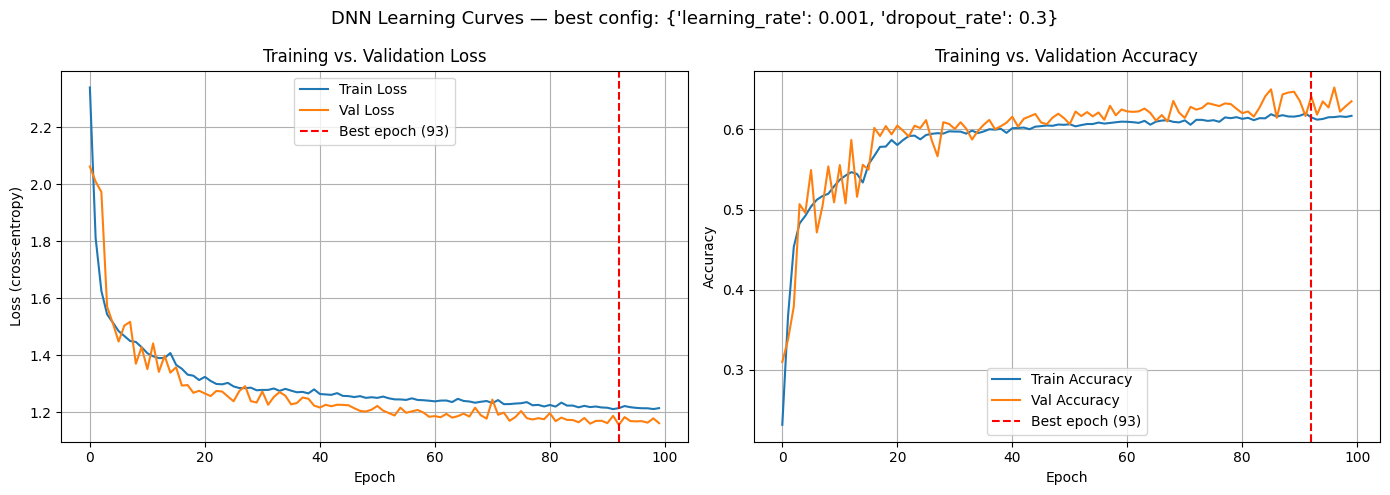

Total epochs run: 100
Best epoch (min val_loss): 93
Best val_loss: 1.1563
Best val_accuracy: 0.6411


In [48]:
epochs_ran  = len(history_diag['loss'])
best_ep_idx = int(np.argmin(history_diag['val_loss']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss curve ---
axes[0].plot(history_diag['loss'],     label='Train Loss')
axes[0].plot(history_diag['val_loss'], label='Val Loss')
axes[0].axvline(best_ep_idx, color='red', linestyle='--', label=f'Best epoch ({best_ep_idx+1})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (cross-entropy)')
axes[0].set_title('Training vs. Validation Loss')
axes[0].legend()
axes[0].grid(True)

# --- Accuracy curve ---
axes[1].plot(history_diag['accuracy'],     label='Train Accuracy')
axes[1].plot(history_diag['val_accuracy'], label='Val Accuracy')
axes[1].axvline(best_ep_idx, color='red', linestyle='--', label=f'Best epoch ({best_ep_idx+1})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs. Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f'DNN Learning Curves — best config: {best_config}', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Total epochs run: {epochs_ran}')
print(f'Best epoch (min val_loss): {best_ep_idx + 1}')
print(f'Best val_loss: {history_diag["val_loss"][best_ep_idx]:.4f}')
print(f'Best val_accuracy: {history_diag["val_accuracy"][best_ep_idx]:.4f}')

## 10. Final Model

Retrain on train plus validation data for the selected number of epochs, then evaluate on the test set.

The code below trains the final model on train+validation and evaluates on test data.

In [49]:
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])

print(f'Final model: config={best_config}, epochs={best_epoch}')
print(f'Training on {X_train_val.shape[0]} samples (train + val combined)')

final_model, final_optimizer = build_model(N_FEATURES, N_CLASSES, **best_config)

# ReduceLROnPlateau cuts the learning rate when training loss plateaus
lr_schedule = optim.lr_scheduler.ReduceLROnPlateau(
    final_optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

final_history = train_model(
    final_model, final_optimizer,
    X_train_val, y_train_val,
    validation_data=None,
    epochs=best_epoch,
    batch_size=BATCH_SIZE,
    class_weight=custom_class_weights,
    patience=None,
    lr_scheduler=lr_schedule,
    verbose=1,
)

final_test_metrics = evaluate_intrusion_model(
    final_model, X_test, y_test, BENIGN_LABEL,
    'Final Test (DNN retrained on train+val)'
)

Final model: config={'learning_rate': 0.001, 'dropout_rate': 0.3}, epochs=93
Training on 1095126 samples (train + val combined)
Epoch 1/93: loss=2.2466 acc=0.2550
Epoch 2/93: loss=1.7319 acc=0.4036
Epoch 3/93: loss=1.5756 acc=0.4662
Epoch 4/93: loss=1.5457 acc=0.4762
Epoch 5/93: loss=1.4779 acc=0.5095
Epoch 6/93: loss=1.4481 acc=0.5184
Epoch 7/93: loss=1.4480 acc=0.5164
Epoch 8/93: loss=1.4186 acc=0.5335
Epoch 9/93: loss=1.3869 acc=0.5462
Epoch 10/93: loss=1.3838 acc=0.5494
Epoch 11/93: loss=1.3775 acc=0.5541
Epoch 12/93: loss=1.3766 acc=0.5557
Epoch 13/93: loss=1.3696 acc=0.5583
Epoch 14/93: loss=1.3590 acc=0.5625
Epoch 15/93: loss=1.3470 acc=0.5702
Epoch 16/93: loss=1.3289 acc=0.5792
Epoch 17/93: loss=1.3178 acc=0.5842
Epoch 18/93: loss=1.3070 acc=0.5888
Epoch 19/93: loss=1.3046 acc=0.5887
Epoch 20/93: loss=1.3134 acc=0.5845
Epoch 21/93: loss=1.3055 acc=0.5885
Epoch 22/93: loss=1.2985 acc=0.5916
Epoch 23/93: loss=1.2955 acc=0.5916
Epoch 24/93: loss=1.3442 acc=0.5698
Epoch 25/93: loss

## 11. Save Final Model

Save the PyTorch checkpoint, including weights and the settings needed to rebuild the network.

The code below saves the checkpoint with weights and architecture settings.

In [50]:
save_dir = Path('../data/artifacts/DNN')
save_dir.mkdir(parents=True, exist_ok=True)

# Save the PyTorch model
model_path = save_dir / f'dnn_{FEATURE_VERSION}.pt'
torch.save({
    'model_state_dict': final_model.state_dict(),
    'n_features':       N_FEATURES,
    'n_classes':        N_CLASSES,
    'dropout_rate':     best_config['dropout_rate'],
}, model_path)
print(f'Saved final model to: {model_path}')

# Save training history for later comparison
history_df = pd.DataFrame(final_history)
history_path = save_dir / f'dnn_{FEATURE_VERSION}_history.csv'
history_df.to_csv(history_path, index_label='epoch')
print(f'Saved training history to: {history_path}')

# Quick reload verification
checkpoint = torch.load(model_path, map_location=device)
reloaded = DNN(checkpoint['n_features'], checkpoint['n_classes'],
               dropout_rate=checkpoint['dropout_rate']).to(device)
reloaded.load_state_dict(checkpoint['model_state_dict'])
test_prob = predict_proba(reloaded, X_test[:5], batch_size=BATCH_SIZE)
print(f'\nReload verification — prediction shape: {test_prob.shape} (expected (5, {N_CLASSES}))')

Saved final model to: ..\data\artifacts\dnn_out.pt
Saved training history to: ..\data\artifacts\dnn_out_history.csv

Reload verification — prediction shape: (5, 34) (expected (5, 34))


## 12. Save Metrics

Save the DNN metrics to JSON. Scaled variants are the meaningful ones for this model.

The code below saves the DNN metrics and confusion matrix for this variant.

In [51]:
import json

metrics_record = {
    'model':                'dnn',
    'variant':              FEATURE_VERSION,
    'best_params':          {**best_config, 'epochs': int(best_epoch)},
    'n_iter':               int(best_epoch),
    'n_classes':            int(N_CLASSES),
    'benign_label':         int(BENIGN_LABEL),
    'train_macro_f1':       float(train_metrics['macro_f1']),
    'val_macro_f1':         float(val_metrics['macro_f1']),
    'test_macro_f1':        float(final_test_metrics['macro_f1']),
    'train_log_loss':       float(train_metrics['log_loss']),
    'val_log_loss':         float(val_metrics['log_loss']),
    'test_log_loss':        float(final_test_metrics['log_loss']),
    'test_benign_fpr':      float(final_test_metrics['benign_fpr']),
    'test_per_class_recall': final_test_metrics['per_class_recall'].tolist(),
    'test_accuracy':        float(final_test_metrics['accuracy']),
    'test_macro_precision': float(final_test_metrics['macro_precision']),
    'test_macro_recall':    float(final_test_metrics['macro_recall'])
}

metrics_path = save_dir / f'dnn_metrics_{FEATURE_VERSION}.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics_record, f, indent=2)

cm_path = save_dir / f'dnn_cm_{FEATURE_VERSION}.npy'
np.save(cm_path, final_test_metrics['confusion_matrix'])

print(f'Saved metrics to:          {metrics_path}')
print(f'Saved confusion matrix to: {cm_path}')

Saved metrics to:          ..\data\artifacts\dnn_metrics_out.json
Saved confusion matrix to: ..\data\artifacts\dnn_cm_out.npy


## 13. Compare Variants

Load all saved DNN metric files and compare the trained variants in one table.

The code below loads saved DNN metric files and builds a variant comparison table.

In [52]:
variant_files = sorted(save_dir.glob('dnn_metrics_*.json'))

if not variant_files:
    print('No metrics files found yet. Re-run the notebook with a FEATURE_VERSION to populate this table.')
else:
    rows = []
    for f in variant_files:
        rec = json.loads(f.read_text())
        bp = rec['best_params']
        rows.append({
            'variant':         rec['variant'],
            'learning_rate':   bp.get('learning_rate'),
            'dropout_rate':    bp.get('dropout_rate'),
            'epochs':          bp.get('epochs'),
            'train_f1':        rec['train_macro_f1'],
            'val_f1':          rec['val_macro_f1'],
            'test_f1':         rec['test_macro_f1'],
            'train_val_gap':   rec['train_macro_f1'] - rec['val_macro_f1'],
            'test_benign_fpr': rec['test_benign_fpr'],
            'test_log_loss':   rec['test_log_loss'],
            'test_accuracy': rec.get('test_accuracy'),
            'test_macro_precision': rec.get('test_macro_precision'),
            'test_macro_recall': rec.get('test_macro_recall')
        })

    comp = pd.DataFrame(rows).sort_values('test_f1', ascending=False).reset_index(drop=True)
    print(f'Comparing {len(comp)} variant(s) of DNN:\n')
    print(comp.to_string(index=False))

    comp_path = save_dir / 'dnn_comparison.csv'
    comp.to_csv(comp_path, index=False)
    print(f'\nSaved comparison table to: {comp_path}')

Comparing 4 variant(s) of DNN:

   variant  learning_rate  dropout_rate  epochs  train_f1   val_f1  test_f1  train_val_gap  test_benign_fpr  test_log_loss  test_accuracy  test_macro_precision  test_macro_recall
out_scaled         0.0010           0.2      95  0.606281 0.600874 0.602731       0.005407         0.415867       0.710990       0.709000              0.632354           0.644668
    scaled         0.0010           0.2      98  0.604259 0.599446 0.601188       0.004813         0.378267       0.712999       0.708975              0.637056           0.644275
       out         0.0010           0.3      93  0.529888 0.528778 0.513915       0.001110         0.472400       0.888008       0.631337              0.583427           0.565138
       raw         0.0005           0.3      72  0.503023 0.501731 0.504169       0.001291         0.475867       0.941001       0.616823              0.559306           0.542873

Saved comparison table to: ..\data\artifacts\dnn_comparison.csv
